In [1]:
# If needed on Kaggle:
# !pip install -q wandb

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import wandb


In [2]:
# =========================
# Global config
# =========================
DATA_DIR = "/kaggle/input/datasets/lakshyashrivastava08/oct2017-kermany/OCT"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

NUM_CLASSES = 4
IMAGE_SIZE = 224
DEFAULT_BATCH_SIZE = 32
DEFAULT_EPOCHS = 8  # increase for final retrain
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)
print("Device:", DEVICE)
print("Data root exists:", os.path.exists(DATA_DIR))


Device: cuda
Data root exists: True


In [3]:
# =========================
# Transforms + stratified split
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_train_for_labels = ImageFolder(TRAIN_DIR)
targets = np.array(full_train_for_labels.targets)
all_indices = np.arange(len(targets))

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=0.15,
    stratify=targets,
    random_state=RANDOM_SEED
)

train_dataset_full = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset_full = ImageFolder(TRAIN_DIR, transform=eval_transform)
test_dataset = ImageFolder(TEST_DIR, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)

CLASS_NAMES = full_train_for_labels.classes
print("Classes:", CLASS_NAMES)
print("Train/Val/Test:", len(train_dataset), len(val_dataset), len(test_dataset))


Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Train/Val/Test: 92062 16247 1000


In [6]:
def make_loaders(batch_size=32, num_workers=2):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(DEFAULT_BATCH_SIZE)
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape, labels.shape)


Batch shape: torch.Size([32, 3, 224, 224]) torch.Size([32])


In [10]:
def build_densenet(num_classes=4, dropout=0.2, mode="frozen"):
    model = models.densenet121(weights="IMAGENET1K_V1")

    # New classifier head
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes)
    )

    if mode == "frozen":
        for p in model.features.parameters():
            p.requires_grad = True
    elif mode == "finetune":
        # Freeze everything first
        for p in model.features.parameters():
            p.requires_grad = True
        # Unfreeze last dense block for fine-tuning
        for p in model.features.denseblock4.parameters():
            p.requires_grad = True
        for p in model.features.norm5.parameters():
            p.requires_grad = True
    else:
        raise ValueError("mode must be 'frozen' or 'finetune'")

    return model


In [11]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1

def evaluate_with_cm(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    cm = confusion_matrix(all_labels, all_preds)
    return acc, f1, cm


In [12]:
def train_experiment(config, run_name="run", use_wandb=True):
    if use_wandb:
        wandb.init(project=config.get("project", "oct-densenet"), config=config, name=run_name)
        cfg = wandb.config
    else:
        cfg = config

    train_loader, val_loader, test_loader = make_loaders(cfg["batch_size"], num_workers=2)

    model = build_densenet(
        num_classes=NUM_CLASSES,
        dropout=cfg["dropout"],
        mode=cfg["mode"]
    ).to(DEVICE)

    if cfg["mode"] == "finetune":
        head_params = list(model.classifier.parameters())
        backbone_params = list(model.features.denseblock4.parameters()) + list(model.features.norm5.parameters())
        optimizer = optim.AdamW([
            {"params": backbone_params, "lr": cfg["backbone_lr"]},
            {"params": head_params, "lr": cfg["lr"]}
        ], weight_decay=cfg["weight_decay"])
    else:
        optimizer = optim.AdamW(model.classifier.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_val_f1 = -1
    best_path = f"best_{cfg['mode']}_{run_name}.pt"

    for epoch in range(cfg["epochs"]):
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_path)

        if use_wandb:
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "train_f1": train_f1,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "val_f1": val_f1,
            })

        print(f"[{epoch+1}/{cfg['epochs']}] train_f1={train_f1:.4f} val_f1={val_f1:.4f}")

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    test_acc, test_f1, test_cm = evaluate_with_cm(model, test_loader)

    print("Test Acc:", round(test_acc, 4), "Test Macro-F1:", round(test_f1, 4))
    print("Confusion Matrix:\n", test_cm)

    if use_wandb:
        wandb.log({"test_acc": test_acc, "test_f1": test_f1})
        wandb.finish()

    return {"test_acc": test_acc, "test_f1": test_f1, "best_ckpt": best_path}


In [ ]:
# =========================
# 1) Frozen baseline run
# =========================
baseline_config = {
    "project": "oct-densenet",
    "mode": "frozen",
    "epochs": DEFAULT_EPOCHS,
    "batch_size": DEFAULT_BATCH_SIZE,
    "lr": 1e-3,
    "backbone_lr": 1e-5,  # unused in frozen mode
    "weight_decay": 1e-4,
    "dropout": 0.2,
}

# Make sure you're logged in: wandb.login(key="...")
baseline_result = train_experiment(baseline_config, run_name="baseline_frozen", use_wandb=True)
baseline_result


In [ ]:
# =========================
# 2) Fine-tuned run
# =========================
finetune_config = {
    "project": "oct-densenet",
    "mode": "finetune",
    "epochs": DEFAULT_EPOCHS,
    "batch_size": DEFAULT_BATCH_SIZE,
    "lr": 1e-4,          # classifier LR
    "backbone_lr": 1e-5, # denseblock4 LR
    "weight_decay": 1e-4,
    "dropout": 0.2,
}

finetune_result = train_experiment(finetune_config, run_name="finetune_denseblock4", use_wandb=True)
finetune_result


In [ ]:
# =========================
# 3) W&B sweep setup
# =========================
# Run one sweep at a time by changing `SWEEP_MODE`.

SWEEP_MODE = "finetune"  # "frozen" or "finetune"

sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_f1", "goal": "maximize"},
    "parameters": {
        "project": {"value": "oct-densenet"},
        "mode": {"value": SWEEP_MODE},
        "epochs": {"value": 8},
        "batch_size": {"values": [16, 32, 64]},
        "lr": {"values": [1e-2, 3e-3, 1e-3, 3e-4, 1e-4]},
        "backbone_lr": {"values": [1e-5, 3e-5, 1e-4]},
        "weight_decay": {"values": [0.0, 1e-5, 1e-4, 1e-3]},
        "dropout": {"values": [0.0, 0.2, 0.4]}
    }
}

def sweep_train():
    run = wandb.init()
    cfg = dict(wandb.config)
    train_experiment(cfg, run_name=run.name, use_wandb=True)

# Example:
sweep_id = wandb.sweep(sweep_config, project="oct-densenet")
wandb.agent(sweep_id, function=sweep_train, count=3)


In [ ]:
# =========================
# 4) Final retrain template
# =========================
# After sweeps, fill in your best hyperparameters here and rerun.

best_frozen_config = {
    "project": "oct-densenet",
    "mode": "frozen",
    "epochs": 4,
    "batch_size": 32,
    "lr": 1e-3,
    "backbone_lr": 1e-5,
    "weight_decay": 1e-4,
    "dropout": 0.2,
}

best_finetune_config = {
    "project": "oct-densenet",
    "mode": "finetune",
    "epochs": 4,
    "batch_size": 32,
    "lr": 1e-4,
    "backbone_lr": 1e-5,
    "weight_decay": 1e-4,
    "dropout": 0.2,
}

final_frozen = train_experiment(best_frozen_config, run_name="final_frozen", use_wandb=True)
final_finetune = train_experiment(best_finetune_config, run_name="final_finetune", use_wandb=True)


In [13]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Recreate fine-tuned DenseNet model directly
ft_model = models.densenet121(weights="IMAGENET1K_V1")
in_features = ft_model.classifier.in_features
ft_model.classifier = nn.Sequential(
    nn.Dropout(p=best_finetune_config["dropout"]),
    nn.Linear(in_features, NUM_CLASSES)
)

# Fine-tune structure: unfreeze only denseblock4 + norm5
for p in ft_model.features.parameters():
    p.requires_grad = False
for p in ft_model.features.denseblock4.parameters():
    p.requires_grad = True
for p in ft_model.features.norm5.parameters():
    p.requires_grad = True

ft_model = ft_model.to(DEVICE)

# Load best fine-tune checkpoint
ft_ckpt = finetune_result["best_ckpt"]  # or your explicit filename
ft_model.load_state_dict(torch.load(ft_ckpt, map_location=DEVICE))

criterion = nn.CrossEntropyLoss()
ft_model.eval()

all_preds, all_labels = [], []
running_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        outputs = ft_model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = running_loss / len(test_loader.dataset)
test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
test_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
test_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"Fine-tune Test Loss     : {test_loss:.5f}")
print(f"Fine-tune Test Accuracy : {test_acc:.5f}")
print(f"Fine-tune Test Precision: {test_precision:.5f} (macro)")
print(f"Fine-tune Test Recall   : {test_recall:.5f} (macro)")
print(f"Fine-tune Test F1       : {test_f1:.5f} (macro)")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 162MB/s]


NameError: name 'best_finetune_config' is not defined

In [14]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = build_densenet(mode="frozen")
model = model.to(DEVICE)

# Enable gradients for GradCAM
for p in model.features.denseblock4.parameters():
    p.requires_grad = True

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

model.train()

for images, labels in train_loader:
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.features.denseblock4.denselayer16.conv2]
cam = GradCAM(model=model, target_layers=target_layers)
images, labels = next(iter(test_loader))

input_tensor = images[0].unsqueeze(0).to(DEVICE)

targets = [ClassifierOutputTarget(labels[0].item())]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)[0]

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

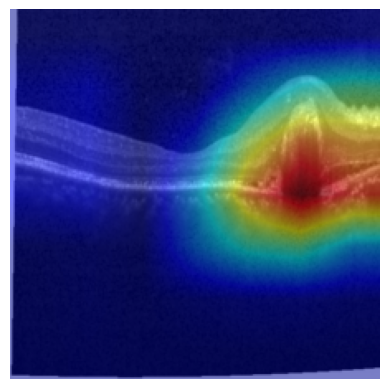

In [22]:
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

img = images[0].permute(1,2,0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis("off")

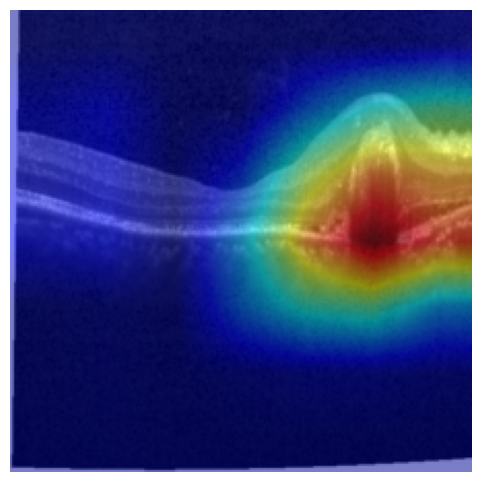

In [23]:
count = 0
for images, labels in test_loader:
    images = images.to(DEVICE)

    outputs = model(images)
    preds = outputs.argmax(dim=1)

    if preds[0] == labels[0]:   # correct prediction
        input_tensor = images[0].unsqueeze(0)

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(labels[0].item())]
        )[0]

        img = images[0].permute(1,2,0).cpu().numpy()
        img = (img - img.min())/(img.max()-img.min())

        visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

        plt.figure(figsize=(6,6))
        plt.imshow(visualization)
        plt.axis("off")
        break

In [24]:
target_images = [
    ("DRUSEN", "DRUSEN-5404227-1.jpeg"),
    ("DRUSEN", "DRUSEN-6322301-3.jpeg"),
    ("DRUSEN", "DRUSEN-7235333-1.jpeg"),
    ("DME", "DME-3665559-1.jpeg"),
    ("DME", "DME-6953909-1.jpeg"),
    ("DME", "DME-999838-1.jpeg"),
]

In [29]:
import torchvision.transforms as transforms

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),   # DenseNet expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet normalization
        std=[0.229, 0.224, 0.225]
    )
])

class_to_idx = {
    "CNV": 0,
    "DME": 1,
    "DRUSEN": 2,
    "NORMAL": 3
}

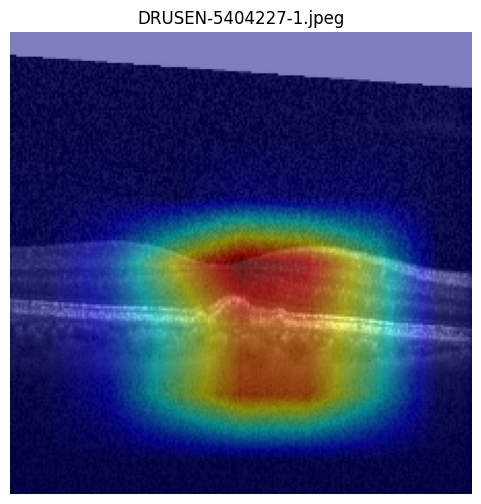

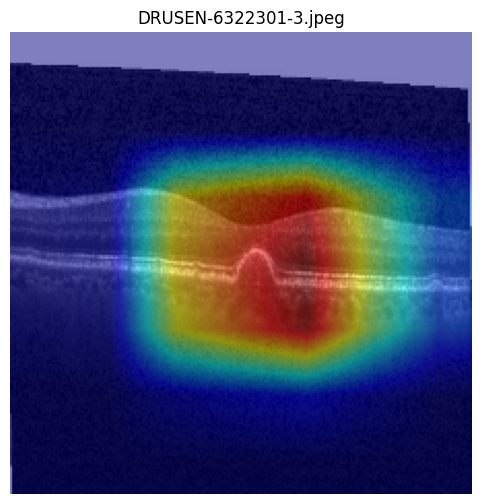

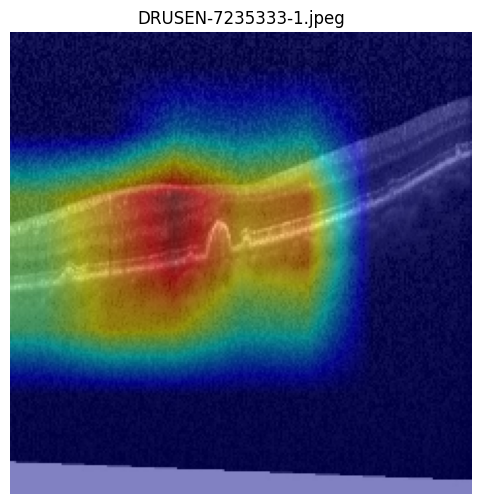

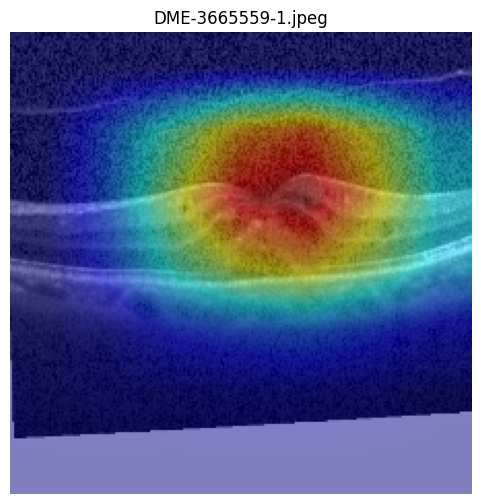

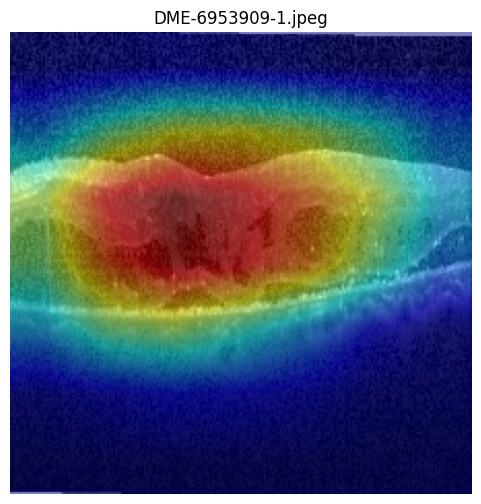

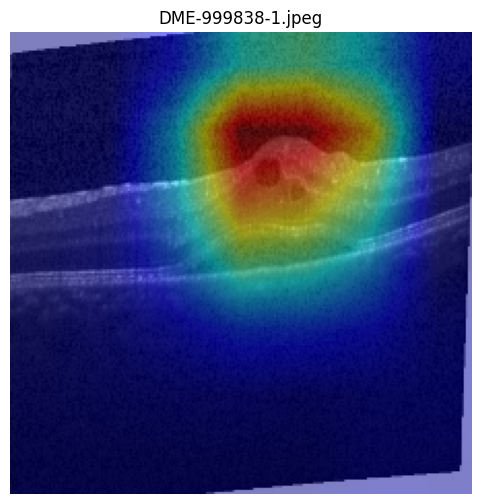

In [33]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

base_path = "/kaggle/input/datasets/lakshyashrivastava08/oct2017-kermany/OCT/test"

for cls, fname in target_images:

    path = os.path.join(base_path, cls, fname)

    img = Image.open(path).convert("RGB")

    input_tensor = test_transform(img).unsqueeze(0).to(DEVICE)

    targets = [ClassifierOutputTarget(class_to_idx[cls])]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    img_np = np.array(img) / 255.0
    img_np = cv2.resize(img_np, (224,224))

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(6,6))
    plt.title(fname)
    plt.imshow(visualization)
    plt.axis("off")
    plt.savefig(f"gradcam_{fname}", bbox_inches="tight", dpi=300)